<a href="https://colab.research.google.com/github/gamzedrn/softito-python-alistirmalari/blob/main/Supermarket_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## KÜTÜPHANELERİ YÜKLE

In [ ]:
# 1. Gerekli kütüphaneleri içe aktaralım
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df = pd.read_csv('/content/supermarket.csv')

print("Şekil (satır, sütun):", df.shape)
print("\nSütun isimleri:\n", df.columns.tolist())
print("\nİlk 5 satır:")
df.head()

Şekil (satır, sütun): (9800, 18)

Sütun isimleri:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

İlk 5 satır:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Eksik Değerler ve Hedef Değişken Dağılımı

In [ ]:
print("=== EKSİK DEĞERLER ===")
print(df.isnull().sum())

print("\n=== HEDEF DEĞİŞKEN DAĞILIMI ===")
print(df['Segment'].value_counts())
print("\nYüzdelik dağılım:")
print(df['Segment'].value_counts(normalize=True).round(3) * 100)

=== EKSİK DEĞERLER ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

=== HEDEF DEĞİŞKEN DAĞILIMI ===
Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

Yüzdelik dağılım:
Segment
Consumer       52.1
Corporate      30.1
Home Office    17.8
Name: proportion, dtype: float64


## Feature Seçimi ve Ön İşleme

In [ ]:
# Kullanacağımız özellikler
features = ['Ship Mode', 'Region', 'Category', 'Sub-Category', 'Sales']
target = 'Segment'

X = df[features].copy()
y = df[target].copy()

# Sales kolonunu sayısal zaten, diğerleri kategorik — onları encode edelim
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Ship Mode', 'Region', 'Category', 'Sub-Category']

le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("=== ENCODE EDİLMİŞ X (ilk 5 satır) ===")
print(X.head())

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nVeri tiplerimiz:")
print(X.dtypes)

=== ENCODE EDİLMİŞ X (ilk 5 satır) ===
   Ship Mode  Region  Category  Sub-Category     Sales
0          2       2         0             4  261.9600
1          2       2         0             5  731.9400
2          2       3         1            10   14.6200
3          3       2         0            16  957.5775
4          3       2         1            14   22.3680

X shape: (9800, 5)
y shape: (9800,)

Veri tiplerimiz:
Ship Mode         int64
Region            int64
Category          int64
Sub-Category      int64
Sales           float64
dtype: object


## Train/Test Split + Ölçeklendirme

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# %80 train, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçeklendirme (özellikle KNN için çok önemli!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("=== VERİ BOYUTLARI ===")
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)

print("\n=== TRAIN SET SINIF DAĞILIMI ===")
print(y_train.value_counts())

print("\n=== TEST SET SINIF DAĞILIMI ===")
print(y_test.value_counts())

=== VERİ BOYUTLARI ===
X_train: (7840, 5)
X_test : (1960, 5)

=== TRAIN SET SINIF DAĞILIMI ===
Segment
Consumer       4081
Corporate      2362
Home Office    1397
Name: count, dtype: int64

=== TEST SET SINIF DAĞILIMI ===
Segment
Consumer       1020
Corporate       591
Home Office     349
Name: count, dtype: int64


## Logistic Regression Modeli

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Modeli kur ve eğit
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Tahmin yap
y_pred_lr = lr_model.predict(X_test_scaled)

# Sonuçlar
print("=== LOGİSTİC REGRESSION SONUÇLARI ===")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_lr), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== LOGİSTİC REGRESSION SONUÇLARI ===

Accuracy: 0.5204

Classification Report:
              precision    recall  f1-score   support

    Consumer       0.52      1.00      0.68      1020
   Corporate       0.00      0.00      0.00       591
 Home Office       0.00      0.00      0.00       349

    accuracy                           0.52      1960
   macro avg       0.17      0.33      0.23      1960
weighted avg       0.27      0.52      0.36      1960

Confusion Matrix:
[[1020    0    0]
 [ 591    0    0]
 [ 349    0    0]]


## KNN Modeli

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# K=5 ile başlayalım (klasik başlangıç noktası)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Tahmin yap
y_pred_knn = knn_model.predict(X_test_scaled)

# Sonuçlar
print("=== KNN SONUÇLARI (k=5) ===")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_knn), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

=== KNN SONUÇLARI (k=5) ===

Accuracy: 0.4495

Classification Report:
              precision    recall  f1-score   support

    Consumer       0.52      0.72      0.60      1020
   Corporate       0.28      0.22      0.25       591
 Home Office       0.21      0.06      0.09       349

    accuracy                           0.45      1960
   macro avg       0.34      0.33      0.31      1960
weighted avg       0.39      0.45      0.40      1960

Confusion Matrix:
[[732 236  52]
 [438 128  25]
 [240  88  21]]


## En İyi K Değerini Bulma

En iyi K: 30
En iyi Accuracy: 0.5000


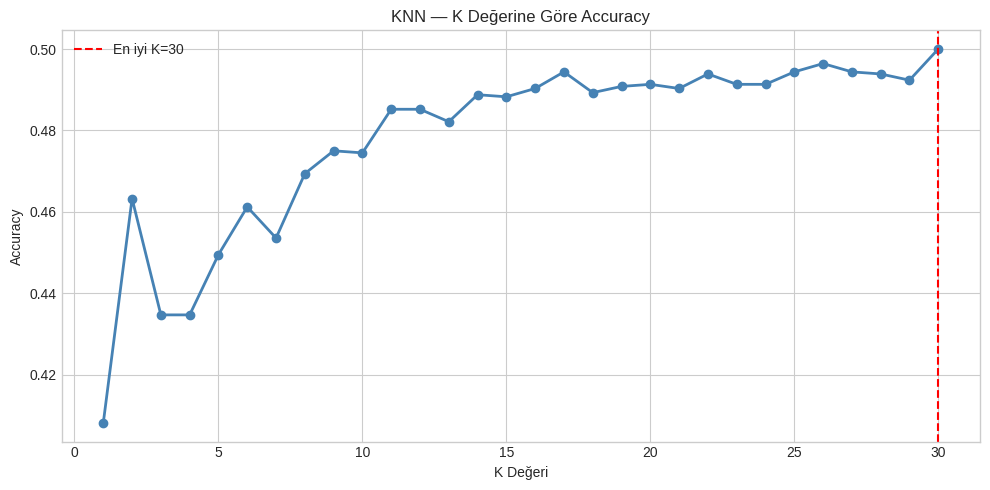

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    accuracies.append(acc)

best_k = k_values[accuracies.index(max(accuracies))]
print(f"En iyi K: {best_k}")
print(f"En iyi Accuracy: {max(accuracies):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'En iyi K={best_k}')
plt.xlabel('K Değeri')
plt.ylabel('Accuracy')
plt.title('KNN — K Değerine Göre Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## En İyi K ile KNN'i Yeniden Çalıştır

In [ ]:
# K aralığını genişletelim, gerçek optimumu bulalım
k_values_extended = range(1, 81)
accuracies_ext = []

for k in k_values_extended:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    accuracies_ext.append(acc)

best_k = k_values_extended[accuracies_ext.index(max(accuracies_ext))]
print(f"En iyi K: {best_k}")
print(f"En iyi Accuracy: {max(accuracies_ext):.4f}")

# En iyi K ile final model
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)

print(f"\n=== KNN SONUÇLARI (k={best_k}) ===")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred_knn_best), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_best))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn_best))

En iyi K: 75
En iyi Accuracy: 0.5173

=== KNN SONUÇLARI (k=75) ===

Accuracy: 0.5173

Classification Report:
              precision    recall  f1-score   support

    Consumer       0.52      0.99      0.68      1020
   Corporate       0.26      0.01      0.02       591
 Home Office       0.00      0.00      0.00       349

    accuracy                           0.52      1960
   macro avg       0.26      0.33      0.23      1960
weighted avg       0.35      0.52      0.36      1960

Confusion Matrix:
[[1007   13    0]
 [ 584    7    0]
 [ 342    7    0]]


## Karşılaştırma Tablosu + Görsel


Metrik                       Log. Reg.   KNN (k=75)
Accuracy                        0.5204       0.5173
F1 - Consumer                   0.6846       0.6820
F1 - Corporate                  0.0000       0.0227
F1 - Home Office                0.0000       0.0000
Macro F1                        0.2282       0.2349


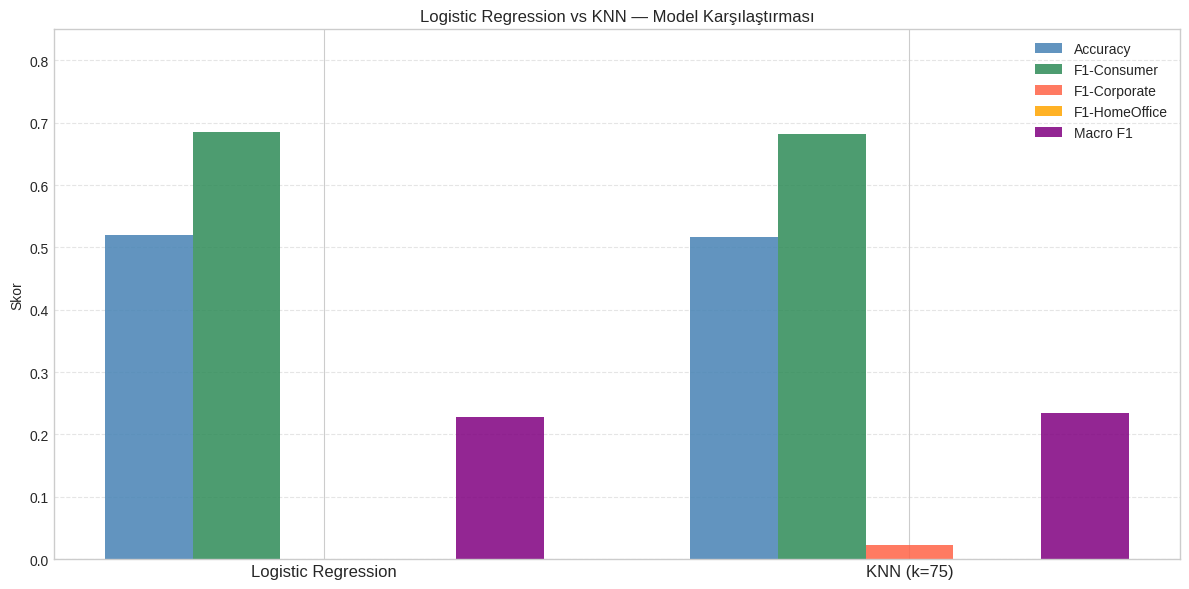

In [ ]:
import numpy as np

models = ['Logistic Regression', f'KNN (k={best_k})']
accuracies_final = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn_best)
]

# Her model için sınıf bazlı F1 skorları
from sklearn.metrics import f1_score

f1_consumer = [
    f1_score(y_test, y_pred_lr, labels=['Consumer'], average=None)[0],
    f1_score(y_test, y_pred_knn_best, labels=['Consumer'], average=None)[0]
]
f1_corporate = [
    f1_score(y_test, y_pred_lr, labels=['Corporate'], average=None)[0],
    f1_score(y_test, y_pred_knn_best, labels=['Corporate'], average=None)[0]
]
f1_homeoffice = [
    f1_score(y_test, y_pred_lr, labels=['Home Office'], average=None)[0],
    f1_score(y_test, y_pred_knn_best, labels=['Home Office'], average=None)[0]
]
macro_f1 = [
    f1_score(y_test, y_pred_lr, average='macro'),
    f1_score(y_test, y_pred_knn_best, average='macro')
]

print("=" * 55)
print(f"{'Metrik':<25} {'Log. Reg.':>12} {'KNN (k=75)':>12}")
print("=" * 55)
print(f"{'Accuracy':<25} {accuracies_final[0]:>12.4f} {accuracies_final[1]:>12.4f}")
print(f"{'F1 - Consumer':<25} {f1_consumer[0]:>12.4f} {f1_consumer[1]:>12.4f}")
print(f"{'F1 - Corporate':<25} {f1_corporate[0]:>12.4f} {f1_corporate[1]:>12.4f}")
print(f"{'F1 - Home Office':<25} {f1_homeoffice[0]:>12.4f} {f1_homeoffice[1]:>12.4f}")
print(f"{'Macro F1':<25} {macro_f1[0]:>12.4f} {macro_f1[1]:>12.4f}")
print("=" * 55)

# Görsel
x = np.arange(len(models))
width = 0.15
metrics = [accuracies_final, f1_consumer, f1_corporate, f1_homeoffice, macro_f1]
labels  = ['Accuracy', 'F1-Consumer', 'F1-Corporate', 'F1-HomeOffice', 'Macro F1']
colors  = ['steelblue', 'seagreen', 'tomato', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    ax.bar(x + i * width, metric, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Skor')
ax.set_title('Logistic Regression vs KNN — Model Karşılaştırması')
ax.set_ylim(0, 0.85)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Confusion Matrix Isı Haritası

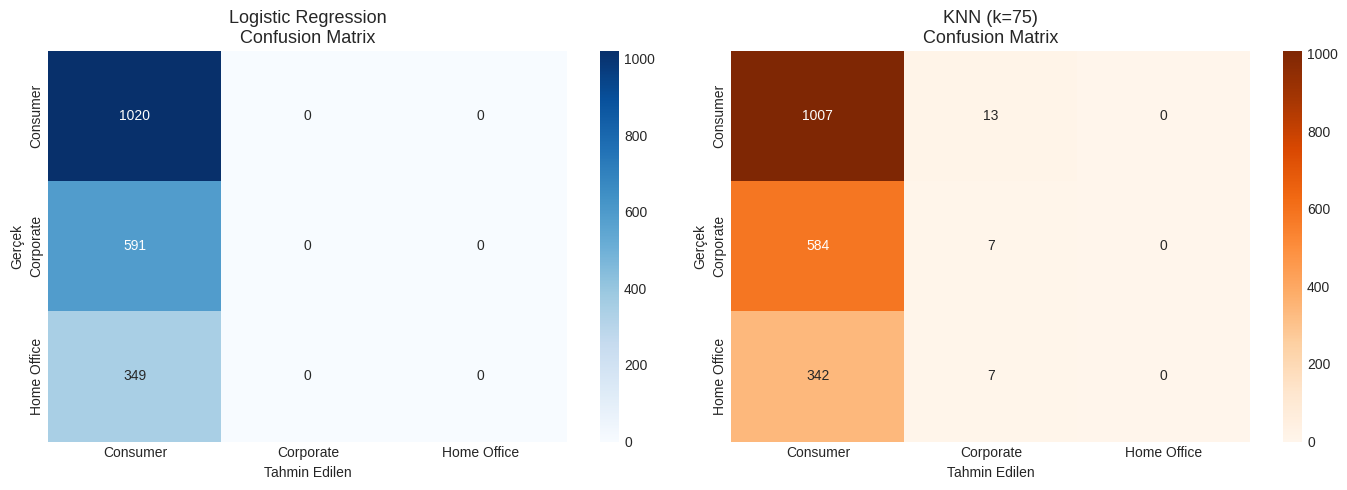

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classes = ['Consumer', 'Corporate', 'Home Office']

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=13)
axes[0].set_xlabel('Tahmin Edilen')
axes[0].set_ylabel('Gerçek')

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn_best)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'KNN (k={best_k})\nConfusion Matrix', fontsize=13)
axes[1].set_xlabel('Tahmin Edilen')
axes[1].set_ylabel('Gerçek')

plt.tight_layout()
plt.show()

## ROC / AUC Eğrisi

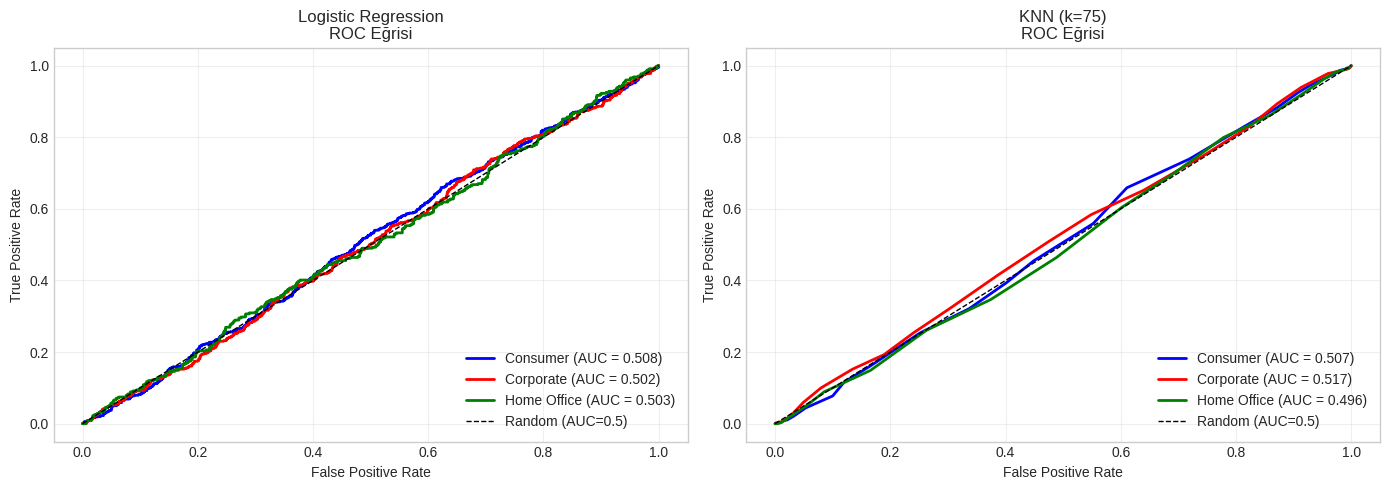

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Sınıfları binary'e çevir (One-vs-Rest)
classes = ['Consumer', 'Corporate', 'Home Office']
y_test_bin = label_binarize(y_test, classes=classes)

# Olasılık tahminleri
y_prob_lr  = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)
y_prob_knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = cycle(['blue', 'red', 'green'])

for ax, y_prob, title in zip(axes,
                              [y_prob_lr, y_prob_knn],
                              ['Logistic Regression', f'KNN (k={best_k})']):
    colors = cycle(['blue', 'red', 'green'])
    for i, (cls, color) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls} (AUC = {roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title}\nROC Eğrisi')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cross Validation + Eğitim Süresi

In [ ]:
from sklearn.model_selection import cross_val_score
import time

# --- CROSS VALIDATION (5-Fold) ---
print("=== 5-FOLD CROSS VALIDATION ===\n")

# Logistic Regression
start = time.time()
cv_lr = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled, y_train, cv=5, scoring='accuracy'
)
lr_time = time.time() - start

print(f"Logistic Regression:")
print(f"  CV Scores : {[round(s,4) for s in cv_lr]}")
print(f"  Ortalama  : {cv_lr.mean():.4f}")
print(f"  Std       : {cv_lr.std():.4f}")
print(f"  Süre      : {lr_time:.2f} sn\n")

# KNN
start = time.time()
cv_knn = cross_val_score(
    KNeighborsClassifier(n_neighbors=best_k),
    X_train_scaled, y_train, cv=5, scoring='accuracy'
)
knn_time = time.time() - start

print(f"KNN (k={best_k}):")
print(f"  CV Scores : {[round(s,4) for s in cv_knn]}")
print(f"  Ortalama  : {cv_knn.mean():.4f}")
print(f"  Std       : {cv_knn.std():.4f}")
print(f"  Süre      : {knn_time:.2f} sn\n")

# --- KARŞILAŞTIRMA TABLOSU ---
print("=" * 50)
print(f"{'Metrik':<25} {'LR':>10} {'KNN':>10}")
print("=" * 50)
print(f"{'CV Ortalama Acc':<25} {cv_lr.mean():>10.4f} {cv_knn.mean():>10.4f}")
print(f"{'CV Std':<25} {cv_lr.std():>10.4f} {cv_knn.std():>10.4f}")
print(f"{'Eğitim Süresi (sn)':<25} {lr_time:>10.2f} {knn_time:>10.2f}")
print("=" * 50)

=== 5-FOLD CROSS VALIDATION ===

Logistic Regression:
  CV Scores : [np.float64(0.5185), np.float64(0.5204), np.float64(0.5204), np.float64(0.5204), np.float64(0.521)]
  Ortalama  : 0.5202
  Std       : 0.0009
  Süre      : 0.27 sn

KNN (k=75):
  CV Scores : [np.float64(0.5204), np.float64(0.5185), np.float64(0.5115), np.float64(0.521), np.float64(0.5159)]
  Ortalama  : 0.5175
  Std       : 0.0035
  Süre      : 0.57 sn

Metrik                            LR        KNN
CV Ortalama Acc               0.5202     0.5175
CV Std                        0.0009     0.0035
Eğitim Süresi (sn)              0.27       0.57


## Tüm Karşılaştırmaları Tek Görselde Topla

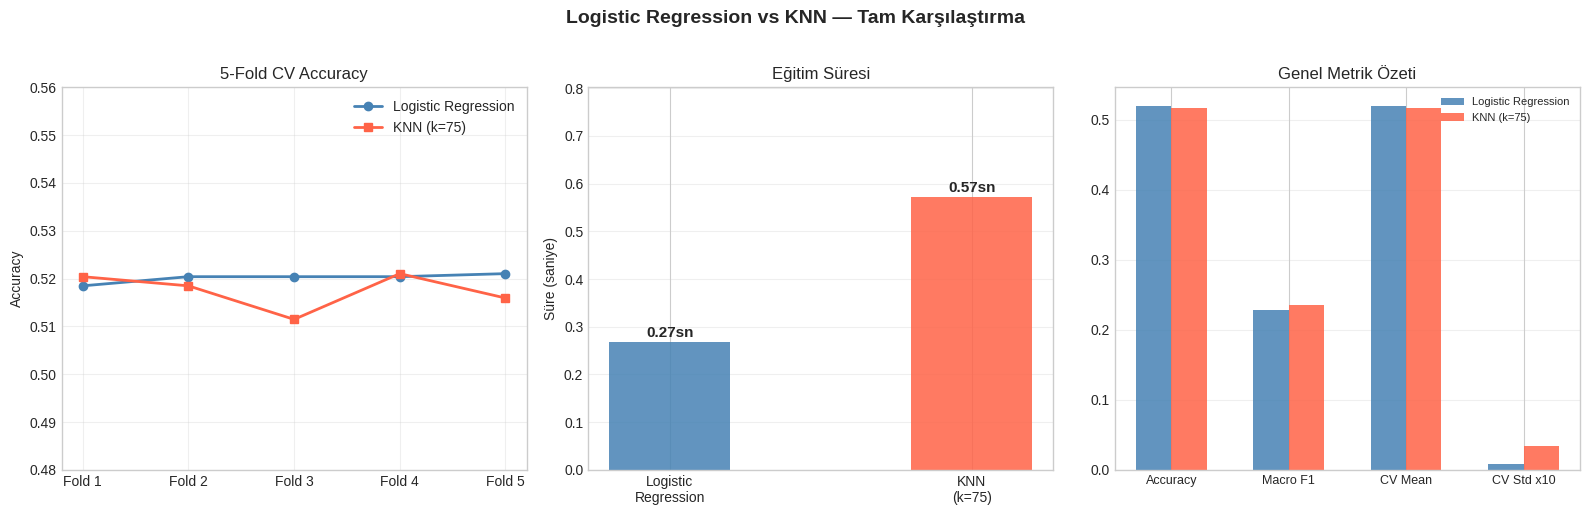

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- GRAFIK 1: CV Accuracy Skorları ---
ax1 = axes[0]
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
ax1.plot(x, cv_lr,  marker='o', label='Logistic Regression', color='steelblue', linewidth=2)
ax1.plot(x, cv_knn, marker='s', label=f'KNN (k={best_k})',   color='tomato',    linewidth=2)
ax1.set_xticks(x)
ax1.set_xticklabels(folds)
ax1.set_ylabel('Accuracy')
ax1.set_title('5-Fold CV Accuracy')
ax1.legend()
ax1.set_ylim(0.48, 0.56)
ax1.grid(True, alpha=0.3)

# --- GRAFIK 2: Eğitim Süresi ---
ax2 = axes[1]
bars = ax2.bar(['Logistic\nRegression', f'KNN\n(k={best_k})'],
               [lr_time, knn_time],
               color=['steelblue', 'tomato'], alpha=0.85, width=0.4)
for bar, val in zip(bars, [lr_time, knn_time]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}sn', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Süre (saniye)')
ax2.set_title('Eğitim Süresi')
ax2.set_ylim(0, max(lr_time, knn_time) * 1.4)
ax2.grid(axis='y', alpha=0.3)

# --- GRAFIK 3: Genel Metrik Özeti ---
ax3 = axes[2]
metrics_names = ['Accuracy', 'Macro F1', 'CV Mean', 'CV Std x10']
lr_vals  = [
    accuracy_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr, average='macro'),
    cv_lr.mean(),
    cv_lr.std() * 10
]
knn_vals = [
    accuracy_score(y_test, y_pred_knn_best),
    f1_score(y_test, y_pred_knn_best, average='macro'),
    cv_knn.mean(),
    cv_knn.std() * 10
]
x3 = np.arange(len(metrics_names))
width = 0.3
ax3.bar(x3 - width/2, lr_vals,  width, label='Logistic Regression', color='steelblue', alpha=0.85)
ax3.bar(x3 + width/2, knn_vals, width, label=f'KNN (k={best_k})',   color='tomato',    alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels(metrics_names, fontsize=9)
ax3.set_title('Genel Metrik Özeti')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Logistic Regression vs KNN — Tam Karşılaştırma', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Genel Kazanan → Logistic Regression — daha hızlı, daha tutarlı, daha kararlı. Ama her iki model de bu veri setiyle gerçek anlamda başarılı sayılmaz. Asıl sorun model değil, özellikler Segment'i ayırt etmiyor.